In [27]:
from config.paths import PAPER_TABLES_DIR, PAPER_FIGURES_DIR, MAE_CRPS_RESULTS_DIR, MODEL_RESULTS_DIR

import os
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import pickle
from tqdm import tqdm
from datetime import datetime, timedelta

# matplotlib config
import matplotlib.pyplot as plt
Paper_width = 6.30045
plt.style.use("paper_style.mplstyle")

full_results_available = False

# Load MAE and CRPS aggregates from every config and delivery 

In [28]:
model_names = ['benchmark_prediction', 'MULTI_prediction', 'CHAIN_prediction']
deliveries = range(96)

probab_approaches = ["benchmark", "hist_insample", "weather_scenarios"]#, "hist_insample"]

config_avg_pinball_results = {}
config_avg_mae_results = {}
for probab_approach in probab_approaches:
    for model_name in model_names:
        if (probab_approach != "benchmark" and model_name == "benchmark_prediction") or (probab_approach == "benchmark" and model_name != "benchmark_prediction"):
            continue

        if probab_approach != "benchmark":
            wasserstein_stopping_crits = [
                True,
                False
            ]

            senarios_sampling_methods = [
                "dual_coeff",
                None
            ]

            required_scenarios_list = [
                'None',
                28,
                182,
            ]
        else:
            wasserstein_stopping_crits = ["False"]
            senarios_sampling_methods = ["None"]
            required_scenarios_list = [
                'None',
                28,
                182
            ]

        repeated_required_scenarios_list = [
            val for val in required_scenarios_list for _ in range(len(wasserstein_stopping_crits))
        ]

        for wasserstein_stopping_crit, scenarios_sampling_method, required_scenarios in zip(wasserstein_stopping_crits*len(required_scenarios_list), senarios_sampling_methods*len(required_scenarios_list), repeated_required_scenarios_list):

            crps_avg = []
            mae_avg = []

            for fil in [
                f for f in os.listdir(MAE_CRPS_RESULTS_DIR) if f.startswith(
                        f'{probab_approach}_{model_name}'
                    ) and f.endswith(
                        f'{wasserstein_stopping_crit}_{scenarios_sampling_method}_{required_scenarios}.csv'
                    ) and int(f.split(f"{model_name}_")[1].split('_')[0]) in deliveries
                ]:
                df = pd.read_csv(os.path.join(MAE_CRPS_RESULTS_DIR, fil))
                crps_avg.append(df['pinball'])

            for fil in [
                f for f in os.listdir(MAE_CRPS_RESULTS_DIR) if f.startswith(
                        f'MAE_{probab_approach}_{model_name}_'
                    ) and f.endswith(
                        f'{wasserstein_stopping_crit}_{scenarios_sampling_method}_{required_scenarios}.csv'
                    ) and int(f.split(f"{model_name}_")[1].split('_')[0]) in deliveries
                ]:
                df = pd.read_csv(os.path.join(MAE_CRPS_RESULTS_DIR, fil))
                mae_avg.append(df['mae'])

            if len(crps_avg) == 0:
                pass

            if len(mae_avg) == 0:
                pass

            print(len(mae_avg), len(crps_avg))

            config_avg_pinball_results[f'{probab_approach}_{model_name}_{wasserstein_stopping_crit}_{scenarios_sampling_method}_{required_scenarios}'] = np.mean(crps_avg)
            config_avg_mae_results[f'{probab_approach}_{model_name}_{wasserstein_stopping_crit}_{scenarios_sampling_method}_{required_scenarios}'] = np.mean(mae_avg)


96 96
96 96
96 96
96 96
96 96
96 96
96 96
96 96
96 96
96 96
96 96
96 96
96 96
96 96
96 96
96 96
96 96
96 96
96 96
96 96
96 96
96 96
96 96
96 96
96 96
96 96
96 96


MAE for all simulation configs:

In [29]:
pd.DataFrame.from_dict(config_avg_mae_results, orient="index", columns=["MAE"]).sort_values('MAE').round(3)

,MAE
weather_scenarios_MULTI_prediction_False_None_None,4.938
weather_scenarios_MULTI_prediction_False_None_182,4.939
weather_scenarios_MULTI_prediction_False_None_28,4.941
weather_scenarios_MULTI_prediction_True_dual_coeff_28,4.941
weather_scenarios_MULTI_prediction_True_dual_coeff_None,4.945
weather_scenarios_MULTI_prediction_True_dual_coeff_182,4.946
weather_scenarios_CHAIN_prediction_False_None_None,4.954
weather_scenarios_CHAIN_prediction_False_None_182,4.955
hist_insample_MULTI_prediction_False_None_None,4.955
weather_scenarios_CHAIN_prediction_False_None_28,4.958


CRPS for all simulation configs:

In [30]:
pd.DataFrame.from_dict(config_avg_pinball_results, orient="index", columns=["CRPS"]).sort_values('CRPS').round(3)

,CRPS
benchmark_benchmark_prediction_False_None_None,1.947
benchmark_benchmark_prediction_False_None_182,1.953
hist_insample_MULTI_prediction_True_dual_coeff_182,1.976
hist_insample_CHAIN_prediction_True_dual_coeff_182,1.980
hist_insample_MULTI_prediction_True_dual_coeff_None,1.993
benchmark_benchmark_prediction_False_None_28,1.995
hist_insample_CHAIN_prediction_False_None_None,2.026
hist_insample_CHAIN_prediction_False_None_182,2.030
hist_insample_MULTI_prediction_False_None_None,2.049
hist_insample_MULTI_prediction_False_None_182,2.052


In [ ]:
def pivot_results(df, col):
    """Pivot the MAE or CRPS table into desirable format for paper"""
    parts = df["config"].str.split("_", expand=True)

    df["model"] = parts[0]

    df["strategy"] = (
        df["config"].str.contains("_MULTI_").map({True: "MULTI"})
        .fillna(df["config"].str.contains("_CHAIN_").map({True: "CHAIN"}))
    )

    # CORRECT method parsing (token-based)
    df["method"] = (
        df["config"].str.contains("_dual_").map({True: "dual_coeff"})
        .fillna(df["config"].str.contains("_FFS_").map({True: "FFS"}))
        .fillna(df["config"].str.contains("_clustering_").map({True: "clustering"}))
    )

    # KEEP "None" as string
    df["window"] = (
        df["config"].str.endswith("28").map({True: 28})
        .fillna(df["config"].str.endswith("182").map({True: 182}))
        .fillna(df["config"].str.endswith("None").map({True: "None"}))
    )

    # FORCE benchmark to survive pivot
    df.loc[df["model"] == "benchmark", ["strategy", "method"]] = (
        "BENCHMARK", "BENCHMARK"
    )
    df["method"] = df["method"].fillna("None")

    wide = df.pivot_table(
        index=["model", "window"],
        columns=["strategy", "method"],
        values=col,
        dropna=False
    )

    wide.columns = [f"{s}_{m}" for s, m in wide.columns]


    # --- Column order for methods ---
    method_order = ["dual_coeff", "FFS", "clustering", "None", "BENCHMARK"]
    strategies = ["MULTI", "CHAIN", "BENCHMARK"]

    # Build desired column order
    desired_columns = []
    for s in strategies:
        for m in method_order:
            col_for_ordering = f"{s}_{m}"
            if col_for_ordering in wide.columns:
                desired_columns.append(col_for_ordering)

    # Reorder columns
    wide = wide[desired_columns]

    # Drop columns that are all NaN, but KEEP BENCHMARK_BENCHMARK
    cols_to_drop = [c for c in wide.columns if wide[c].isna().all() and c != "BENCHMARK_BENCHMARK"]
    wide = wide.drop(columns=cols_to_drop)

    # --- Row order: hist, weather, benchmark ---
    wide = wide.reset_index()
    model_order = ["hist", "weather", "benchmark"]
    wide["model"] = pd.Categorical(wide["model"], categories=model_order, ordered=True)
    wide = wide.sort_values(["model", "window"]).reset_index(drop=True)

    return wide


In [32]:
df = pd.DataFrame.from_dict(config_avg_mae_results, orient="index", columns=["MAE"]).sort_values('MAE').round(3)
df['config'] = df.index
pivotted_df = pivot_results(df, col='MAE')
pivotted_df.to_csv(os.path.join(PAPER_TABLES_DIR, "MAE_results.csv"))
pivotted_df

,model,window,MULTI_dual_coeff,MULTI_None,CHAIN_dual_coeff,CHAIN_None,BENCHMARK_BENCHMARK
0,hist,28.0,4.979,4.979,4.991,4.991,NaN
1,hist,182.0,5.000,4.960,5.013,4.982,NaN
2,hist,None,5.020,4.955,5.045,4.982,NaN
3,weather,28.0,4.941,4.941,4.959,4.958,NaN
4,weather,182.0,4.946,4.939,4.959,4.955,NaN
5,weather,None,4.945,4.938,4.966,4.954,NaN
6,benchmark,28.0,NaN,NaN,NaN,NaN,5.050
7,benchmark,182.0,NaN,NaN,NaN,NaN,4.991
8,benchmark,None,NaN,NaN,NaN,NaN,4.982


In [33]:
df = pd.DataFrame.from_dict(config_avg_pinball_results, orient="index", columns=["CRPS"]).sort_values('CRPS').round(3)
df['config'] = df.index
pivotted_df = pivot_results(df, col='CRPS')
pivotted_df.to_csv(os.path.join(PAPER_TABLES_DIR, "CRPS_results.csv"))
pivotted_df

,model,window,MULTI_dual_coeff,MULTI_None,CHAIN_dual_coeff,CHAIN_None,BENCHMARK_BENCHMARK
0,hist,28.0,2.089,2.090,2.071,2.071,NaN
1,hist,182.0,1.976,2.052,1.980,2.030,NaN
2,hist,None,1.993,2.049,2.063,2.026,NaN
3,weather,28.0,2.271,2.268,2.269,2.267,NaN
4,weather,182.0,2.261,2.250,2.248,2.248,NaN
5,weather,None,2.260,2.247,2.242,2.245,NaN
6,benchmark,28.0,NaN,NaN,NaN,NaN,1.995
7,benchmark,182.0,NaN,NaN,NaN,NaN,1.953
8,benchmark,None,NaN,NaN,NaN,NaN,1.947


# Scenarios number analysis

In [34]:
if full_results_available:
    import os
    import pandas as pd
    import matplotlib.pyplot as plt

    # --- settings ---
    RAW_RESULTS_DIR = MODEL_RESULTS_DIR
    model_names = ['MULTI_prediction']
    probab_approaches = ["hist_insample", "weather_scenarios"]

    # Include all scenario sampling methods
    scenarios_sampling_methods = ["dual_coeff", None]

    # Store results for plotting per method
    scenarios_counts_dict = {
        pa: {method: [] for method in scenarios_sampling_methods} 
        for pa in probab_approaches
    }

    for probab_approach in probab_approaches:
        print(f"Processing {probab_approach}")
        for model_name in model_names:
            print(f"Processing {model_name}")

            required_scenarios = 'None'

            for scenarios_sampling_method in scenarios_sampling_methods:

                if scenarios_sampling_method in ['dual_coeff', 'FFS']: 
                    wasserstein_stopping_crit = True
                else:
                    wasserstein_stopping_crit = False

                scenarios_no = []

                for results_dir in tqdm(os.listdir(RAW_RESULTS_DIR), desc="Directories"):
                    method_str = scenarios_sampling_method if scenarios_sampling_method is not None else "None"
                    folder_suffix = f"{probab_approach}_{required_scenarios}_{wasserstein_stopping_crit}_{method_str}"

                    if results_dir.endswith(folder_suffix):
                        folder_path = os.path.join(RAW_RESULTS_DIR, results_dir)
                        for fil in os.listdir(folder_path):
                            df = pd.read_csv(os.path.join(folder_path, fil))
                            count = len([c for c in df.columns if c.startswith(model_name) and 'MAE' not in c])
                            scenarios_no.append(count)

                # store per method
                scenarios_counts_dict[probab_approach][scenarios_sampling_method].extend(scenarios_no)
    with open("scenarios_counts_dict.pkl", "wb") as f:
        pickle.dump(scenarios_counts_dict, f)

else:
    print("Scenarios number can't be calculated on aggregated results only - you need to run the full simulation!")

Scenarios number can't be calculated on aggregated results only - you need to run the full simulation!


In [35]:
if full_results_available:# List of methods (ensure order is consistent)
    methods = ["dual_coeff", None]

    # Initialize dict to store summary stats
    summary_dict = {}

    for pa in scenarios_counts_dict.keys():
        for method in methods:
            col_name = f"{pa}_{method if method is not None else 'None'}"
            counts = np.array(scenarios_counts_dict[pa][method])
            # compute stats; fallback to NaN if no data
            summary_dict[col_name] = [
                np.mean(counts) if len(counts) > 0 else np.nan,
                np.percentile(counts, 25) if len(counts) > 0 else np.nan,
                np.median(counts) if len(counts) > 0 else np.nan,
                np.percentile(counts, 75) if len(counts) > 0 else np.nan
            ]

    # Create DataFrame
    summary_df = pd.DataFrame(summary_dict, index=["Mean", "Q1", "Median", "Q3"])

    # Optional: sort columns alphabetically for readability
    summary_df = summary_df[sorted(summary_df.columns)]

    summary_df.to_csv(os.path.join(PAPER_TABLES_DIR, 'scenarios_number_distribution.csv'))
    summary_df

# CRPS plots

In [36]:
model_names = ['benchmark_prediction', 'MULTI_prediction', 'CHAIN_prediction']
deliveries = range(96)

probab_approaches = ["benchmark", "hist_insample", "weather_scenarios"]#, "hist_insample"]


fig_crps_percentiles = go.Figure()
fig_crps_path_steps = go.Figure()
fig_mae_path_steps = go.Figure()

x_matplotlib = []
y_matplotlib = []
names_matplotlib = []

for probab_approach in probab_approaches:
    for model_name in model_names:
        if (probab_approach != "benchmark" and model_name == "benchmark_prediction") or (probab_approach == "benchmark" and model_name != "benchmark_prediction"):
            continue

        if probab_approach != "benchmark":
            wasserstein_stopping_crits = [
                True,
                False
            ]

            senarios_sampling_methods = [
                "dual_coeff",
                None
            ]

            required_scenarios_list = [
                'None',
                28,
                182,
            ]
        else:
            wasserstein_stopping_crits = ["False"]
            senarios_sampling_methods = ["None"]
            required_scenarios_list = [
                'None',
                28,
            ]

        repeated_required_scenarios_list = [
            val for val in required_scenarios_list for _ in range(len(wasserstein_stopping_crits))
        ]

        for wasserstein_stopping_crit, scenarios_sampling_method, required_scenarios in zip(wasserstein_stopping_crits*len(required_scenarios_list), senarios_sampling_methods*len(required_scenarios_list), repeated_required_scenarios_list):

            all_pinball_by_tau = []
            all_pinball_by_path = []

            for fil in [
                f for f in os.listdir(MAE_CRPS_RESULTS_DIR) if f.startswith(
                        f'{probab_approach}_{model_name}'
                    ) and f.endswith(
                        f'{wasserstein_stopping_crit}_{scenarios_sampling_method}_{required_scenarios}.csv'
                    ) and int(f.split(f"{model_name}_")[1].split('_')[0]) in deliveries
                ]:
                df = pd.read_csv(os.path.join(MAE_CRPS_RESULTS_DIR, fil))

                all_pinball_by_tau.append(df.groupby('tau').mean()['pinball'])
                all_pinball_by_path.append(df.groupby('path_idx').mean()['pinball'])

            pinball_by_tau = pd.concat(all_pinball_by_tau, axis=1).mean(axis=1)
            pinball_by_path = pd.concat(all_pinball_by_path, axis=1).mean(axis=1)

            fig_crps_percentiles.add_trace(go.Scatter(
                x=pinball_by_tau.index,
                y=pinball_by_tau,
                mode='lines+markers',
                name=f'{probab_approach}_{model_name}_{wasserstein_stopping_crit}_{scenarios_sampling_method}_{required_scenarios}',
            ))

            fig_crps_path_steps.add_trace(go.Scatter(
                x=pinball_by_path.index,
                y=pinball_by_path,
                mode='lines+markers',
                name=f'{probab_approach}_{model_name}_{wasserstein_stopping_crit}_{scenarios_sampling_method}_{required_scenarios}',
            ))

            all_mae_by_path = []

            for fil in [
                f for f in os.listdir(MAE_CRPS_RESULTS_DIR) if f.startswith(
                        f'MAE_{probab_approach}_{model_name}_'
                    ) and f.endswith(
                        f'{wasserstein_stopping_crit}_{scenarios_sampling_method}_{required_scenarios}.csv'
                    ) and int(f.split(f"{model_name}_")[1].split('_')[0]) in deliveries
                ]:
                df = pd.read_csv(os.path.join(MAE_CRPS_RESULTS_DIR, fil))

                all_mae_by_path.append(df.groupby('path_idx').mean()['mae'])

            mae_by_path = pd.concat(all_mae_by_path, axis=1).mean(axis=1)

            fig_mae_path_steps.add_trace(go.Scatter(
                x=mae_by_path.index,
                y=mae_by_path,
                mode='lines+markers',
                name=f'{probab_approach}_{model_name}_{wasserstein_stopping_crit}_{scenarios_sampling_method}_{required_scenarios}',
            ))
            if (
                (
                    (model_name == 'MULTI_prediction' and scenarios_sampling_method == 'dual_coeff') or
                    (model_name == 'MULTI_prediction' and scenarios_sampling_method is None) or
                    (model_name == 'benchmark_prediction' and scenarios_sampling_method == 'None')
                ) and
                required_scenarios == 'None'
            ):
                x_matplotlib.append(pinball_by_tau.index)
                y_matplotlib.append(pinball_by_tau)
                names_matplotlib.append(f'{probab_approach}_{model_name}_{wasserstein_stopping_crit}_{scenarios_sampling_method}_{required_scenarios}')


99
99
99
99
99
99
99
99
99
99


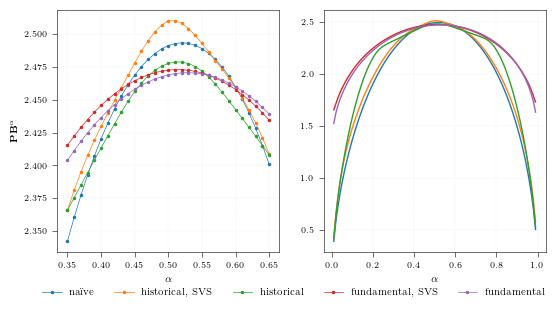

In [37]:
fig, axs = plt.subplots(ncols=2, figsize=(Paper_width, 0.5*Paper_width))

ax = axs[0]
labels = ['naïve', 'historical, SVS', 'historical', 'fundamental, SVS', 'fundamental']
for x, y, label in zip(x_matplotlib, y_matplotlib, labels):
    # plot all scenarios
    print(len(y))
    ax.plot(x[34:65], y.iloc[34:65], label=label, markersize=1.5, lw=0.5, linestyle='-', marker='o')
ax.set_xlabel(r"$\alpha$")
ax.set_ylabel(r"$\mathbf{PB}^{\alpha}$")
ax.tick_params(axis='x')
ax.tick_params(axis='y')
ax.grid(True, linestyle="--", alpha=0.6, lw=0.1)

ax = axs[1]
for x, y, label in zip(x_matplotlib, y_matplotlib, labels):
    # plot all scenarios
    print(len(y))
    ax.plot(x, y, lw=1, linestyle='-')
ax.set_xlabel(r"$\alpha$")
ax.tick_params(axis='x')
ax.tick_params(axis='y')
ax.grid(True, linestyle="--", alpha=0.6, lw=0.1)

fig.legend(loc="lower center", ncol=5, frameon=False, bbox_to_anchor=(0.5, -0.06))
plt.savefig(os.path.join(PAPER_FIGURES_DIR, "global_pinball.pdf"), bbox_inches="tight")

plt.show()


# Strategy illustration plots

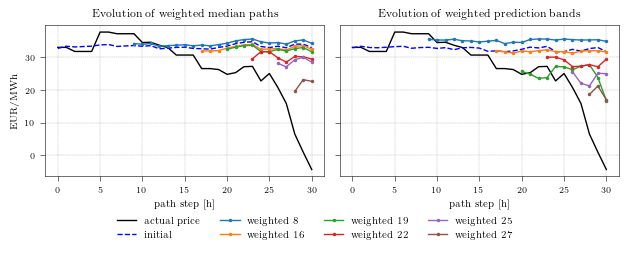

In [40]:
actual = [32.94797814, 32.94797814, 31.7       , 31.7       , 31.7       ,
       37.61083333, 37.61083333, 37.1       , 37.1       , 37.1       ,
       34.40642857, 34.5       , 33.59181818, 32.88544715, 30.6       ,
       30.6       , 30.6       , 26.47782609, 26.47782609, 26.1824    ,
       24.725     , 25.22696154, 27.05111111, 27.15      , 22.70862857,
       24.97583333, 20.72134146, 15.8221466 ,  6.5248605 ,  0.97721519,
       -4.29343254]


initial_band = [32.81299431, 33.26230241, 32.91340438, 32.82281986, 32.98421612,
       33.16894639, 33.27108325, 32.67286014, 32.88924837, 32.96828049,
       32.62556593, 32.8559181 , 32.23784803, 32.8213579 , 32.93359077,
       32.7209241 , 31.74303093, 31.8833363 , 31.60832041, 31.86847865,
       32.35739854, 33.01675112, 32.77096463, 33.25023429, 31.64781524,
       31.62389105, 32.34396757, 31.79589159, 32.58156136, 32.89241418,
       31.62857648]

initial_median = [32.63989322, 33.29903547, 33.07730324, 33.191334  , 33.30989344,
       33.69801622, 33.81664342, 33.22405019, 33.38211136, 33.48976511,
       33.28308025, 33.47065072, 32.50538345, 32.70207865, 32.93694397,
       32.99405131, 32.62070617, 32.52598029, 32.40053924, 32.92053529,
       33.33039096, 34.04938229, 34.48529272, 34.66307332, 33.20808245,
       32.87911469, 33.29271061, 32.81653812, 33.92099948, 33.93937363,
       32.87853067]

with open(os.path.join("Data", "DATA_ANALYSIS_EXAMPLES", "bands_risk_seeking_hist_fore_no_svs_intrapath_adjustment_example.pkl"), "rb") as f:
    other_bands = pickle.load(f)

with open(os.path.join("Data", "DATA_ANALYSIS_EXAMPLES", "median_hist_fore_no_svs_intrapath_adjustment_example.pkl"), "rb") as f:
    other_medians = pickle.load(f)

fig, axs = plt.subplots(ncols=2, figsize=(Paper_width,0.35*Paper_width), sharex=True, sharey=True)

x = np.arange(len(actual))

ax = axs[0]
# Plot actual
ax.plot(x, actual, 'k-', lw=1, label='actual price')

# Plot median unweighted
ax.plot(x, initial_median, 'b--', lw=1, label='initial')

# Plot weighted medians
weighted_medians = {
    8: other_medians[8],
    16: other_medians[16],
    19: other_medians[19],
    22: other_medians[22],
    25: other_medians[25],
    27: other_medians[27],
    28: other_medians[28]
}

for i, (idx, median) in enumerate(weighted_medians.items()):
    if idx < 28:
        ax.plot(np.arange(len(median)) + idx + 1, median, marker='o', markersize=1.5, linestyle='-', 
                lw=1, label=fr'weighted {idx}')
ax.tick_params(axis='x')
ax.tick_params(axis='y')
ax.set_ylabel('EUR/MWh')
ax.set_xlabel('path step [h]')
ax.grid(True, linestyle='--', linewidth=0.3)

ax = axs[1]
# Plot actual
ax.plot(x, actual, 'k-', lw=1)

# Plot median unweighted
ax.plot(x, initial_band, 'b--', lw=1)

# Plot weighted medians
weighted_bands = {
    8: other_bands[8],
    16: other_bands[16],
    19: other_bands[19],
    22: other_bands[22],
    25: other_bands[25],
    27: other_bands[27],
    28: other_bands[28]
}

for i, (idx, band) in enumerate(weighted_bands.items()):
    if idx < 28:
        ax.plot(np.arange(len(band)) + idx + 1, band, marker='o', markersize=1.5, linestyle='-', 
                lw=1)
ax.tick_params(axis='x')
ax.tick_params(axis='y')
ax.set_xlabel('path step [h]')
# ax.set_ylabel('EUR/MWh')

axs[0].set_title("Evolution of weighted median paths")
axs[1].set_title("Evolution of weighted prediction bands")

fig.legend(loc="lower center", ncol=4, frameon=False, bbox_to_anchor=(0.5, -0.13))
plt.tight_layout()
ax.grid(True, linestyle='--', linewidth=0.3)
plt.savefig(os.path.join(PAPER_FIGURES_DIR, "weighted_paths_example.pdf"), bbox_inches="tight")
plt.show()


# Weather scenarios example

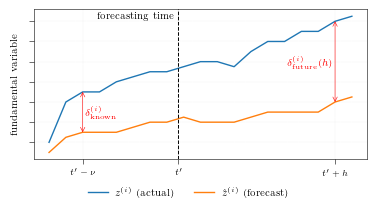

In [41]:
# Sample increasing series
actual = np.array([2, 6, 7, 7, 8, 8.5, 9, 9, 9.5, 10, 10, 9.5, 11, 12, 12, 13, 13, 14, 14.5])
forecast = np.array([1, 2.5, 3, 3, 3, 3.5, 4, 4, 4.5, 4, 4, 4, 4.5, 5, 5, 5, 5, 6, 6.5])

# Create 15-minute intervals for x-axis (time only)
start_time = datetime.strptime("13:00", "%H:%M")  # starting at 08:00
x_times = [start_time + timedelta(minutes=15*i) for i in range(len(actual))]

# Indices to illustrate deltas
i_known, i_fore = 2, 17

# Create figure/axes
fig, ax = plt.subplots(figsize=(0.6*Paper_width, 0.3 * Paper_width))

# Plot Actual and Forecast
ax.plot(x_times, actual, linewidth=1, label="$z^{(i)}$ (actual)")
ax.plot(x_times, forecast, linewidth=1, label="$\hat{z}^{(i)}$ (forecast)")

# Helper to draw a vertical double-headed arrow and label
def draw_delta(idx, label, direction='right'):
    y0, y1 = forecast[idx], actual[idx]
    x = x_times[idx]
    
    ax.annotate(
        "",
        xy=(x, y0),
        xytext=(x, y1),
        arrowprops=dict(
    arrowstyle="<->",
    lw=0.4,
    color="red",
    shrinkA=0,
    shrinkB=0,
    mutation_scale=8   # smaller than default
)
    )
    
    # Label positioning
    if direction.lower() == 'left':
        x_offset = -timedelta(minutes=2)
        ha = "right"
    else:
        x_offset = timedelta(minutes=2)
        ha = "left"
    
    ax.text(
        x + x_offset,
        (y0 + y1) / 2.0,
        label,
        va="center",
        ha=ha,
        color="red"
    )

# Draw the two deltas
draw_delta(i_known, r"$\delta^{(i)}_{\mathrm{known}}$")
draw_delta(i_fore,  r"$\delta^{(i)}_{\mathrm{future}}(h)$", direction='left')

# Add vertical line at first delta (i_known)
ax.axvline(x_times[8]  - timedelta(minutes=5), color="black", linestyle="--", linewidth=0.7)

# Add vertical text label for forecasting time
ax.text(x_times[8]  - timedelta(minutes=8), 14.5,
        "forecasting time",
        va="center", ha="right", color="black")
# --- Keep ticks but remove ALL labels ---
ax.set_xticklabels([])   # remove x tick labels only
ax.set_yticklabels([])   # remove y tick labels

# --- Add ONLY the 3 custom labeled ticks ---
xtick_positions = [
    x_times[i_known],                    # t' - ν
    x_times[8] - timedelta(minutes=5),   # t'
    x_times[i_fore]                      # t' + h
]

xtick_labels = [
    r"$t' - \nu$",
    r"$t'$",
    r"$t' + h$"
]

ax.set_xticks(xtick_positions)
ax.set_xticklabels(xtick_labels)

ax.grid(True, linestyle='--', linewidth=0.3)

# Style
ax.set_ylabel("fundamental variable")
ax.grid(True, linestyle="--", alpha=0.6, lw=0.1)
ax.tick_params(axis='x')
ax.tick_params(axis='y')
fig.legend(loc="lower center", ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.1))
fig.tight_layout()

plt.savefig(os.path.join(PAPER_FIGURES_DIR, "weather_scenarios.pdf"), bbox_inches='tight')

plt.show()
